In [12]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,MinMaxScaler,RobustScaler,label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score,f1_score,recall_score,precision_score,confusion_matrix,roc_auc_score,balanced_accuracy_score

N_SPLITS = 3
RANDOM_STATE=42
skf = StratifiedKFold(n_splits=N_SPLITS,shuffle=True,random_state=RANDOM_STATE)

data_path = Path.cwd().parent / "data" / "playground-series-s6e6" 
df_train = pd.read_csv(data_path / "train.csv")
df_test = pd.read_csv(data_path / "test.csv")

df_exp = df_train.copy()
df_test_exp = df_test.copy()


df_exp = df_exp.drop(["id"],axis=1)
X_test = df_test_exp.drop(["id"],axis=1)

X_train,y_train = df_exp.drop(["class"],axis=1), df_exp["class"]

target_col = ["class"]
categorical_cols = ["spectral_type","galaxy_population"]
numerical_cols = [col for col in X_train.columns if col not in categorical_cols + target_col ]
objects_for_test = {}




In [13]:
X_test.isna().any(axis=1).sum()

np.int64(0)

In [14]:
def ohe(X_train:pd.DataFrame,X_test:pd.DataFrame):
    encoder = OneHotEncoder(sparse_output=False,handle_unknown="ignore",drop="first").set_output(transform="pandas")
    spectral_type = encoder.fit_transform(X_train[categorical_cols])
    spectral_type_test = encoder.transform(X_test[categorical_cols])
    objects_for_test["ohe"] = encoder
    return pd.concat([X_train.drop(categorical_cols,axis=1),spectral_type],axis=1), pd.concat([X_test.drop(categorical_cols,axis=1),spectral_type_test],axis=1)

def outlier_scan(X:pd.DataFrame,threshold_pct=0.01):
    columns_with_outliers = []
    for col in numerical_cols:
        Q1=X[col].quantile(0.25)
        Q3=X[col].quantile(0.75)
        IQR = Q3-Q1
        
        lower_bound = Q1-1.5*IQR
        upper_bound = Q3+1.5*IQR

        outliers = X[(X[col] > upper_bound) | (X[col]<lower_bound)]
        outlier_pct = len(outliers) / len(X)

        if outlier_pct > threshold_pct:
            print(f"Column {col} exceeds the threshold for acceptable outliers: {outlier_pct*100}% are outliers")
            columns_with_outliers.append(col)

    return columns_with_outliers

def feature_engineering(d:pd.DataFrame):

    for a,b in [('u','g'),('g','r'),('r','i'),('i','z'),('u','r'),('g','z'),('u','z')]:
        d[f'{a}_{b}'] = d[a] - d[b]

    d['redshift']= d['redshift'].clip(lower=0)
    d['rs_log']= np.log1p(d['redshift'])
    d['rs_sq'] = d['redshift'] ** 2
    d['rs_cbrt'] = np.cbrt(d['redshift'])

    bands = d[['u','g','r','i','z']].values
    d['mag_mean']  = bands.mean(1)
    d['mag_std']   = bands.std(1)
    d['mag_range'] = bands.max(1) - bands.min(1)
    d['mag_skew']  = d[['u','g','r','i','z']].skew(axis=1)

    d['rs_x_ug']   = d['rs_log'] * d['u_g']
    d['rs_x_gr']   = d['rs_log'] * d['g_r']
    d['rs_x_mean'] = d['rs_log'] * d['mag_mean']
    
    return d
        
def preprocessing_pipeline(X_train:pd.DataFrame,y_train:pd.DataFrame,X_test:pd.DataFrame):
    le = LabelEncoder()
    y_encoded =pd.Series(le.fit_transform(y_train))
    objects_for_test["label_enc"] = le
    outlier_cols =outlier_scan(X_train)
    print(X_test.shape)

    X_train = feature_engineering(X_train)
    X_test = feature_engineering(X_test)
    print(X_test.isna().any(axis=1).sum())
    print(X_test.shape)

    X_train,X_test = ohe(X_train,X_test)
    print(X_test.isna().any(axis=1).sum())
    print(X_test.shape)

    r_scaler = RobustScaler().set_output(transform="pandas")
    mm_scaler = MinMaxScaler().set_output(transform="pandas")

    scaled_robust = r_scaler.fit_transform(X_train[outlier_cols])
    scaled_mm = mm_scaler.fit_transform(X_train.drop(outlier_cols,axis=1))

    scaled_robust_test = r_scaler.transform(X_test[outlier_cols])
    scaled_mm_test = mm_scaler.transform(X_test.drop(outlier_cols,axis=1))
    print(X_test.isna().any(axis=1).sum())
    print(X_test.shape)
    objects_for_test["robust_scaler"] = r_scaler
    objects_for_test["mm_scaler"] = mm_scaler 

    X_train = pd.concat([scaled_robust,scaled_mm],axis=1)
    X_test = pd.concat([scaled_robust_test,scaled_mm_test],axis=1)
    print(X_test.isna().any(axis=1).sum())
    return X_train,y_encoded,X_test

X_train,y_train,X_test = preprocessing_pipeline(X_train,y_train,X_test)

Column redshift exceeds the threshold for acceptable outliers: 9.10890677530151% are outliers
(247435, 10)
0
(247435, 27)
0
(247435, 29)
0
(247435, 29)
0


In [15]:
X_test

,redshift,alpha,delta,u,g,r,i,z,u_g,g_r,...,mag_std,mag_range,mag_skew,rs_x_ug,rs_x_gr,rs_x_mean,spectral_type_G/K,spectral_type_M,spectral_type_O/B,galaxy_population_Red_Sequence
0,-0.097785,0.335311,0.431311,0.838507,0.597541,0.671141,0.515250,0.496519,0.810727,0.528298,...,0.176838,0.191360,0.607888,0.799044,0.440657,0.156570,1.0,0.0,0.0,1.0
1,0.528003,0.609472,0.619186,0.881999,0.625027,0.643211,0.495204,0.528583,0.838359,0.571950,...,0.224892,0.223780,0.763494,0.819007,0.485935,0.277585,0.0,1.0,0.0,1.0
2,-0.390226,0.482119,0.166904,0.689155,0.350674,0.392258,0.288931,0.296747,0.785843,0.531704,...,0.138213,0.138787,0.574606,0.790562,0.432690,0.073769,1.0,0.0,0.0,0.0
3,-0.615442,0.513607,0.170459,0.819240,0.567379,0.638319,0.530149,0.595368,0.806743,0.527780,...,0.113888,0.115102,0.849282,0.788742,0.424106,0.028331,1.0,0.0,0.0,1.0
4,0.684945,0.618010,0.343354,0.888739,0.646693,0.674059,0.468816,0.489390,0.834649,0.566894,...,0.256130,0.257739,0.665189,0.820402,0.488111,0.302650,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247430,1.023786,0.688918,0.694983,0.764384,0.580869,0.717264,0.583312,0.652124,0.749783,0.480037,...,0.016665,0.017667,0.181976,0.784207,0.422898,0.354221,0.0,0.0,0.0,0.0
247431,0.724544,0.630055,0.726926,0.759837,0.535327,0.646851,0.564303,0.615952,0.766483,0.494822,...,0.023431,0.026525,0.730623,0.791713,0.433986,0.302697,0.0,0.0,0.0,0.0
247432,-0.325744,0.646876,0.647773,0.825355,0.624868,0.595004,0.466680,0.466307,0.786010,0.607806,...,0.201885,0.195001,0.604507,0.791284,0.454969,0.102460,0.0,1.0,0.0,1.0
247433,1.002185,0.976102,0.210232,0.740413,0.523015,0.603026,0.538558,0.567584,0.754159,0.517326,...,0.031906,0.027523,0.509817,0.786365,0.455416,0.335079,1.0,0.0,0.0,0.0


In [17]:
import optuna
from functools import partial

def objective_lr(trial,X,y,skf):
    C = trial.suggest_float(
        "C",
        1e-4,100,log=True
    )

    scores = []
    for fold,(train_idx,val_idx) in enumerate(skf.split(X,y),start=1):
        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]
        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        model = LogisticRegression(class_weight="balanced",max_iter=1000,solver="lbfgs",C=C)
        model.fit(X_train,y_train)
        preds =model.predict(X_val)

        score = recall_score(y_val,preds,average="macro")

        scores.append(score)

    return np.mean(scores)


study = optuna.create_study(
    direction="maximize",
    study_name="logreg_study"
)

objective_lr = partial(objective_lr,X=X_train,y=y_train,skf=skf)
study.optimize(objective_lr,n_trials=100,show_progress_bar=True,n_jobs=-1)

print(f"Best score: {study.best_value}")
print(f"Best params: {study.best_params}")
        

[I 2026-06-15 19:45:11,241] A new study created in memory with name: logreg_study
Best trial: 0. Best value: 0.866303:   1%|          | 1/100 [01:45<2:54:37, 105.83s/it]

[I 2026-06-15 19:46:57,009] Trial 0 finished with value: 0.8663032434739034 and parameters: {'C': 0.00013650364166737416}. Best is trial 0 with value: 0.8663032434739034.


Best trial: 4. Best value: 0.874218:   2%|▏         | 2/100 [02:05<1:29:50, 55.00s/it] 

[I 2026-06-15 19:47:15,695] Trial 4 finished with value: 0.8742180645910441 and parameters: {'C': 0.00024602051950768384}. Best is trial 4 with value: 0.8742180645910441.


Best trial: 4. Best value: 0.874218:   2%|▏         | 2/100 [04:01<1:29:50, 55.00s/it]

...

[I 2026-06-15 22:15:23,836] Trial 98 finished with value: 0.9231685958849511 and parameters: {'C': 26.380819261482902}. Best is trial 32 with value: 0.9279752574808621.


Best trial: 32. Best value: 0.927975:  99%|█████████▉| 99/100 [2:30:31<00:37, 37.81s/it]

[I 2026-06-15 22:15:42,947] Trial 95 finished with value: 0.92701814008961 and parameters: {'C': 27.141091848476904}. Best is trial 32 with value: 0.9279752574808621.


Best trial: 96. Best value: 0.928133: 100%|██████████| 100/100 [2:31:03<00:00, 90.63s/it]

[I 2026-06-15 22:16:14,285] Trial 96 finished with value: 0.9281332549700867 and parameters: {'C': 63.36051905321572}. Best is trial 96 with value: 0.9281332549700867.
Best score: 0.9281332549700867
Best params: {'C': 63.36051905321572}


In [18]:
# Best results phase 1 
# Best score: 0.9120996107977397
# Best params: {'C': 2.2727211432676113, 'class_weight': 'balanced'}

model = LogisticRegression(class_weight="balanced",max_iter=1000,solver="lbfgs",C=63.36051905321572)
model.fit(X_train,y_train)
preds =model.predict(X_test)


In [19]:
labels = objects_for_test["label_enc"].inverse_transform(preds)
ids = df_test["id"].values
submission = pd.DataFrame({"id":ids,"class":labels})
submission.to_csv(Path.cwd().parent / "submissions" / "submission_v1_LR_optuna_HT.csv",index=False)


In [6]:
import optuna

def objective_gbdt(trial):
    
    n_estimators = trial.suggest_categorical(
        "n_estimators",[50,100,200,500,1000]
    )

    subsample = trial.suggest_categorical(
        "subsample", [0.5,0.8,1.0]
    )

    max_depth = trial.suggest_categorical(
        "max_depth", [3,8]
    )
    
    scores = []
    for fold,(train_idx,val_idx) in enumerate(skf.split(X,y),start=1):
        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]
        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        # model = LogisticRegression(class_weight="balanced",max_iter=1000,solver="lbfgs",C=C)
        model = GradientBoostingClassifier(n_estimators=n_estimators,subsample=subsample,max_depth=max_depth)
        model.fit(X_train,y_train)
        preds =model.predict(X_val)

        score = recall_score(y_val,preds,average="macro")

        scores.append(score)
        break

    return np.mean(scores)


study = optuna.create_study(
    direction="maximize",
    study_name="logreg_study"
)

study.optimize(objective_gbdt,n_trials=30,show_progress_bar=True,n_jobs=-1)

print(f"Best score: {study.best_value}")
print(f"Best params: {study.best_params}")

[I 2026-06-15 14:48:09,959] A new study created in memory with name: logreg_study
  0%|          | 0/30 [00:00<?, ?it/s]

Best trial: 5. Best value: 0.92932:   3%|▎         | 1/30 [36:21<17:34:14, 2181.20s/it]

[I 2026-06-15 15:24:31,078] Trial 5 finished with value: 0.9293203193809157 and parameters: {'n_estimators': 50, 'subsample': 0.5, 'max_depth': 3}. Best is trial 5 with value: 0.9293203193809157.


Best trial: 5. Best value: 0.92932:   3%|▎         | 1/30 [47:49<23:06:56, 2869.54s/it]


KeyboardInterrupt: 

[I 2026-06-15 16:37:26,985] Trial 12 finished with value: 0.929103114300204 and parameters: {'n_estimators': 50, 'subsample': 1.0, 'max_depth': 3}. Best is trial 5 with value: 0.9293203193809157.
[I 2026-06-15 17:09:11,108] Trial 6 finished with value: 0.9387861759242306 and parameters: {'n_estimators': 100, 'subsample': 1.0, 'max_depth': 3}. Best is trial 6 with value: 0.9387861759242306.
[I 2026-06-15 17:16:58,986] Trial 11 finished with value: 0.9493537156852758 and parameters: {'n_estimators': 50, 'subsample': 0.8, 'max_depth': 8}. Best is trial 11 with value: 0.9493537156852758.
[I 2026-06-15 18:01:00,810] Trial 0 finished with value: 0.9499733430767096 and parameters: {'n_estimators': 100, 'subsample': 0.5, 'max_depth': 8}. Best is trial 0 with value: 0.9499733430767096.
[I 2026-06-15 18:18:40,431] Trial 12 finished with value: 0.9498827233339915 and parameters: {'n_estimators': 50, 'subsample': 0.5, 'max_depth': 8}. Best is trial 12 with value: 0.9498827233339915.
[I 2026-06-15 

([<matplotlib.axis.YTick at 0x7f76657116a0>,
 [Text(0, 0, 'spectral_type_G/K'),
  Text(0, 1, 'spectral_type_O/B'),
  Text(0, 2, 'galaxy_population_Red_Sequence'),
  Text(0, 3, 'i_z'),
  Text(0, 4, 'delta'),
  Text(0, 5, 'r'),
  Text(0, 6, 'u_g'),
  Text(0, 7, 'alpha'),
  Text(0, 8, 'mag_mean'),
  Text(0, 9, 'u'),
  Text(0, 10, 'i'),
  Text(0, 11, 'z'),
  Text(0, 12, 'r_i'),
  Text(0, 13, 'mag_skew'),
  Text(0, 14, 'rs_x_mean'),
  Text(0, 15, 'g'),
  Text(0, 16, 'u_r'),
  Text(0, 17, 'rs_x_ug'),
  Text(0, 18, 'mag_range'),
  Text(0, 19, 'g_r'),
  Text(0, 20, 'spectral_type_M'),
  Text(0, 21, 'rs_x_gr'),
  Text(0, 22, 'rs_sq'),
  Text(0, 23, 'mag_std'),
  Text(0, 24, 'u_z'),
  Text(0, 25, 'rs_cbrt'),
  Text(0, 26, 'redshift'),
  Text(0, 27, 'rs_log'),
  Text(0, 28, 'g_z')])

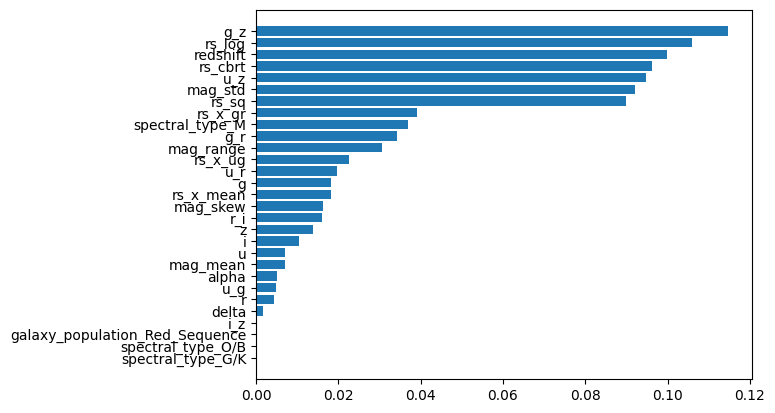

In [23]:
feature_importances = model.feature_importances_
feature_names = np.array(list(X.columns))
sorted_idx = np.argsort(feature_importances)

pos = np.arange(len(feature_importances))
import matplotlib.pyplot as plt
plt.barh(pos,feature_importances[sorted_idx])
plt.yticks(pos,np.array(feature_names[sorted_idx]))

In [ ]:
def feature_importance_lr(model):
    for i in range(3):
        print(np.argsort(np.abs(model.coef_[i])))
        print(np.sort(np.abs(model.coef_[i])))

    # results suggest most imp features as 0,3,4,5,6,7s

[11 10  1  8  9  2  5  0  3  7  4  6]
[ 0.06084272  0.0746778   0.20109097  0.27888     0.28180194  0.71317307
  2.28770784  2.68553252  9.42694215 11.7238898  12.44548179 14.02475212]
[10  9  8  1 11  2  0  5  4  7  6  3]
[ 0.12989645  0.13152307  0.32076255  0.43105161  1.15522202  1.63932667
  4.16586146  4.88334866  4.93139136 10.3838889  20.1959347  29.57248036]
[ 8 10  9  1  2 11  7  5  6  0  4  3]
[ 0.04188256  0.05521864  0.15027887  0.22996063  0.92615361  1.0943793
  1.3400009   2.59564083  6.17118258  6.85139397  7.51409043 20.14553821]
